# Pycistopic

In [1]:
import sys
import scipy as sc
import pandas as pd
sys.path
tmpDir = '/home/bt392/ry/'

In [2]:
import warnings
warnings.simplefilter(action='ignore')
import pycisTopic
pycisTopic.__version__

'1.0.2.dev7+gda26088'

In [16]:
# Project directory
projDir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus_sc/'
# Output directory
outDir = projDir + 'pycistopic/'
import os
if not os.path.exists(outDir):
    os.makedirs(outDir)
work_dir = outDir

In [4]:
# counts matrix needs to be transformed
count_matrix = sc.io.mmread(projDir + 'atac.mtx')
count_matrix_pd = pd.DataFrame(count_matrix.toarray())

In [11]:
cluster_metadata = pd.read_csv(projDir + 'meta_subsampled.txt')
peaks = pd.read_csv(projDir + 'peaks.txt')

In [13]:
count_matrix_pd = pd.DataFrame(count_matrix.toarray())

In [16]:
count_matrix_pd.index =  peaks['x'].tolist()
count_matrix_pd.columns = cluster_metadata['cell'].tolist()

In [21]:
count_matrix_pd = count_matrix_pd.T # Unclear to me if this has to be done or not currently
count_matrix_pd.columns = count_matrix_pd.columns.astype(str)

## 1. Creating a cisTopic object

In [24]:
# Create cisTopic object
from pycisTopic.cistopic_class import *
# count_matrix=pd.read_csv(projDir+'epiblast_blood_atac_mtx.tsv', sep='\t')
# count_matrix = count_matrix.set_index('cell')

#path_to_blacklist='/staging/leuven/stg_00002/lcb/cbravo/Multiomics_pipeline/pycisTopic/blacklist/hg19-blacklist.v2.bed'
cistopic_obj = create_cistopic_object(fragment_matrix=count_matrix_pd) #, path_to_blacklist=path_to_blacklist)
# Adding cell information
cluster_metadata = cluster_metadata.set_index('cell')
cistopic_obj.add_cell_data(cluster_metadata)

2024-10-30 15:55:11,720 cisTopic     INFO     Converting fragment matrix to sparse matrix
2024-10-30 15:57:09,264 cisTopic     INFO     Creating CistopicObject
2024-10-30 15:57:17,459 cisTopic     INFO     Done!


In [25]:
# Save without doublets
with open(outDir + 'cisTopicObject.pkl', 'wb') as f:
  pickle.dump(cistopic_obj, f)

## 2. Run models

In [7]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [27]:
# #path_to_mallet_binary="/rds/project/rds-SDzz0CATGms/users/bt392/miniconda3/envs/scenicplus/bin/mallet"
# path_to_mallet_binary="/rds/project/rds-SDzz0CATGms/users/bt392/software/github/Mallet/bin/mallet"
# os.environ['MALLET_MEMORY'] = '100G'
# # Run models
# models= run_cgs_models_mallet(path_to_mallet_binary, #run_cgs_models(
#                     cistopic_obj,
#                     n_topics=[2,3], #[2,4,10,15,25,35]
#                     n_cpu=30,
#                     n_iter=500,
#                     random_state=555,
#                     alpha=50,
#                     alpha_by_topic=True,
#                     eta=0.1,
#                     eta_by_topic=False,
#                     tmp_path  =tmpDir, #Use SCRATCH if many models or big data set
#                     save_path=None)

# # Save
# import pickle
# with open(outDir+'models_500.pkl', 'wb') as f:
#   pickle.dump(models, f)

In [9]:
%%bash
sbatch
#!/bin/bash
#SBATCH -p icelake-himem #skylake-himem #icelake #skylake #-himem #cclake
#SBATCH -A gottgens-sl2-cpu
### Modify this according to your Ray workload.
#SBATCH --nodes=1
##SBATCH --exclusive # maybe don't specify exclusive 
#SBATCH --tasks-per-node=1
#SBATCH --time 12:00:00
### Modify this according to your Ray workload.
#SBATCH --cpus-per-task=30
#SBATCH --mem-per-cpu=5GB
#SBATCH --gpus-per-task=0

python /rds/project/rds-SDzz0CATGms/users/bt392/software/github/pycisTopic/model_scripts/runModels_lda_mallet.py \
        -i /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus_sc/pycistopic/cisTopicObject.pkl \
        -o /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus_sc/pycistopic/models_500_mallet.pkl \
        -nt 15,25,35 \
        -c 30 \
        -it 500 \
        -a 50 \
        -abt True \
        -e 0.1 \
        -ebt False \
        -sp /home/bt392/ry/ \
        -s 555 \
        -td /home/bt392/ry

Submitted batch job 63454908


## 3. Model selection

In [4]:
# Load cisTopic object
import pickle
infile = open(outDir + 'models_500_mallet.pkl', 'rb')
models = pickle.load(infile)
infile.close()

In [5]:
models

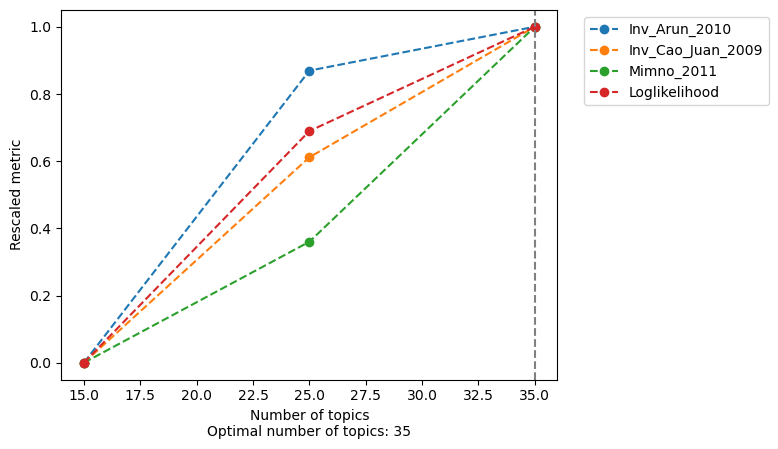

In [12]:
from pycisTopic.lda_models import *
os.mkdir(outDir+'models')
model=evaluate_models(models,
                     select_model=None,
                     return_model=True,
                     metrics=['Arun_2010','Cao_Juan_2009', 'Minmo_2011','loglikelihood'],
                     plot_metrics=False,
                     save= outDir + 'models/model_selection.pdf')

In [14]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [17]:
cistopic_obj.add_LDA_model(model)
pickle.dump(cistopic_obj,
            open(os.path.join(work_dir, 'cisTopicObject.pkl'), 'wb'))

In [ ]:
# # Save
# with open(outDir + 'epiblast_blood_cisTopicObject.pkl', 'wb') as f:
#   pickle.dump(cistopic_obj, f)

## 4. Clustering & Visualisation

In [18]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [19]:
from pycisTopic.clust_vis import *
find_clusters(cistopic_obj,
                 target  = 'cell',
                 k = 10,
                 res = [0.6],
                 prefix = 'pycisTopic_',
                 scale = True,
                 split_pattern = '-')

2024-11-01 09:36:47,281 cisTopic     INFO     Finding neighbours


In [20]:
run_umap(cistopic_obj,
                 target  = 'cell', scale=True)

2024-11-01 09:36:50,417 cisTopic     INFO     Running UMAP


In [21]:
run_tsne(cistopic_obj,
                 target  = 'cell', scale=True)

2024-11-01 09:37:22,305 cisTopic     INFO     Running TSNE


In [23]:
cistopic_obj.cell_data.columns

Index(['cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc',
       'cisTopic_log_nr_acc', 'sample_id', 'barcode', 'sample', 'nFeature_RNA',
       'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA',
       'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call',
       'celltype', 'celltype.score', 'closest.cell', 'TSSEnrichment_atac',
       'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac',
       'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC',
       'pycisTopic_leiden_10_0.6'],
      dtype='object')

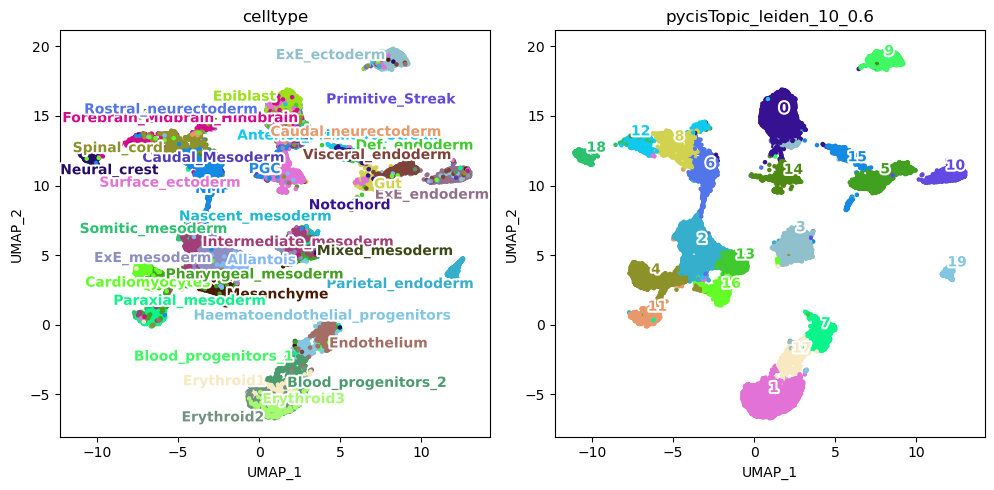

In [24]:
os.mkdir(outDir+'/visualization')
plot_metadata(cistopic_obj,
                 reduction_name='UMAP',
                 variables=['celltype', 'pycisTopic_leiden_10_0.6'], # Labels from RNA and new clusters
                 target='cell', num_columns=3,
                 text_size=10,
                 dot_size=5,
                 figsize=(15,5),
                 save= outDir + 'visualization/dimensionality_reduction_label.pdf')

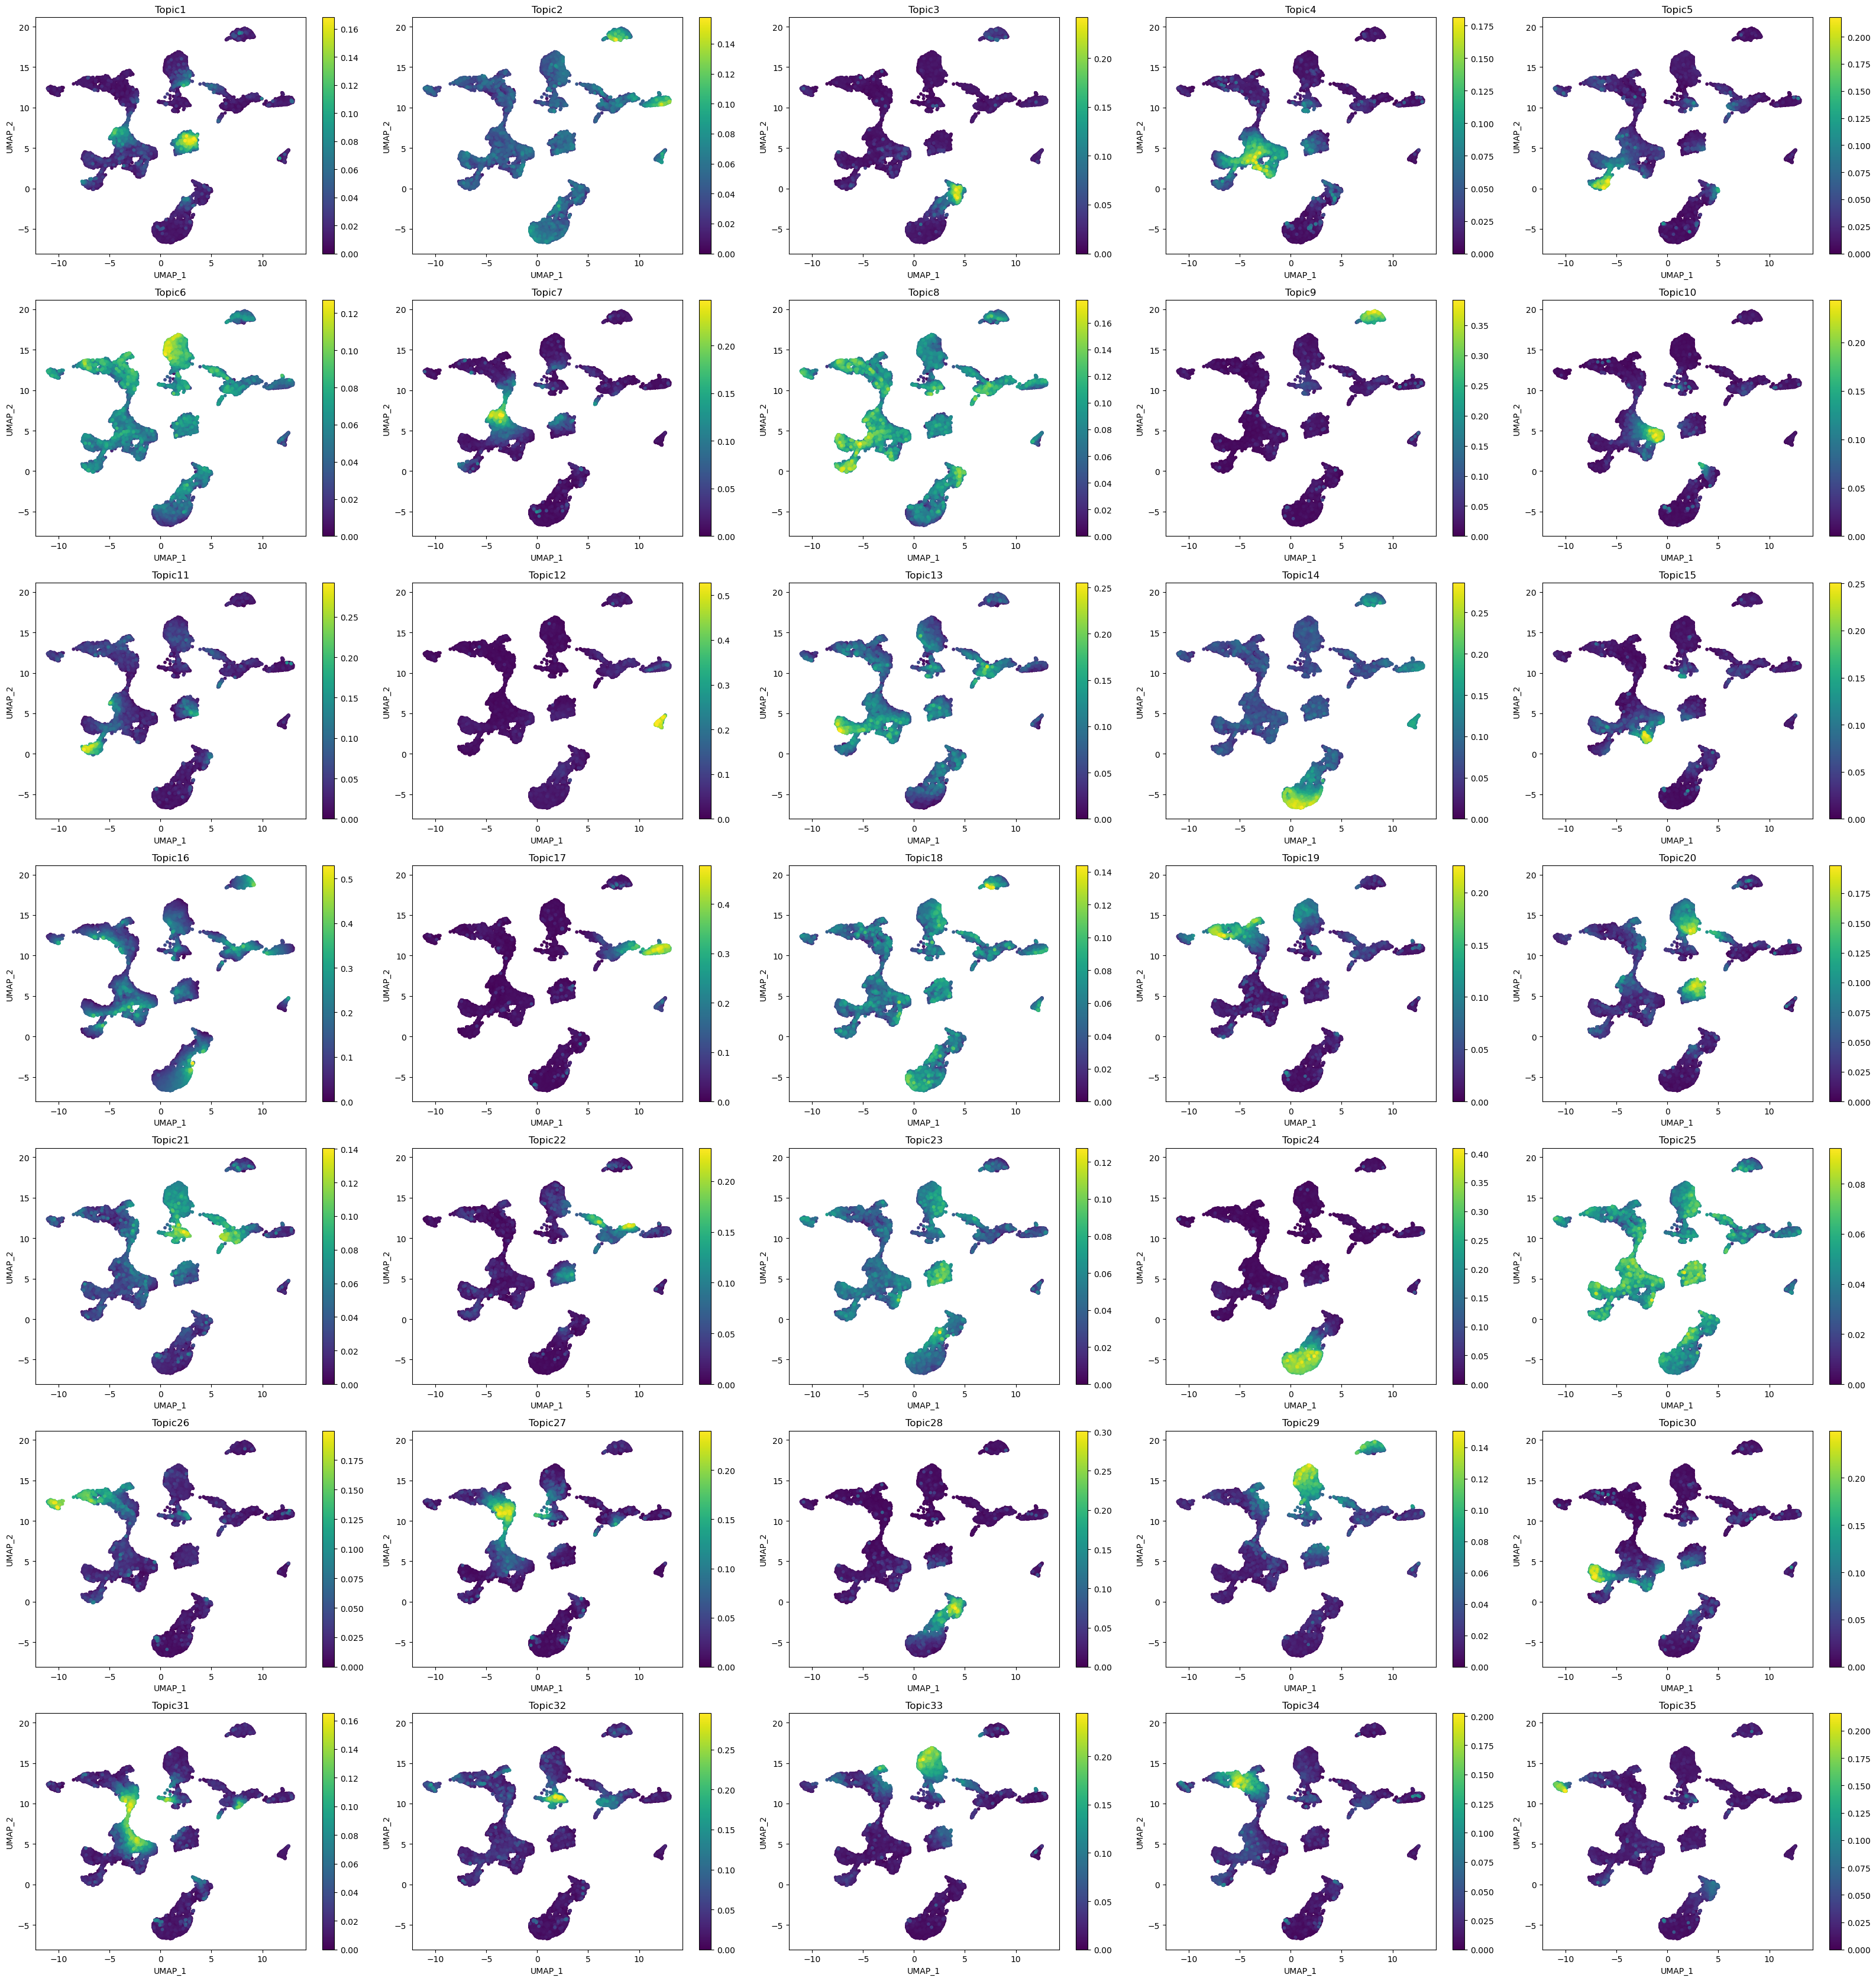

In [25]:
plot_topic(cistopic_obj,
            reduction_name = 'UMAP',
            target = 'cell',
            num_columns=5,
            save= outDir + 'visualization/dimensionality_reduction_topic_contr.pdf')

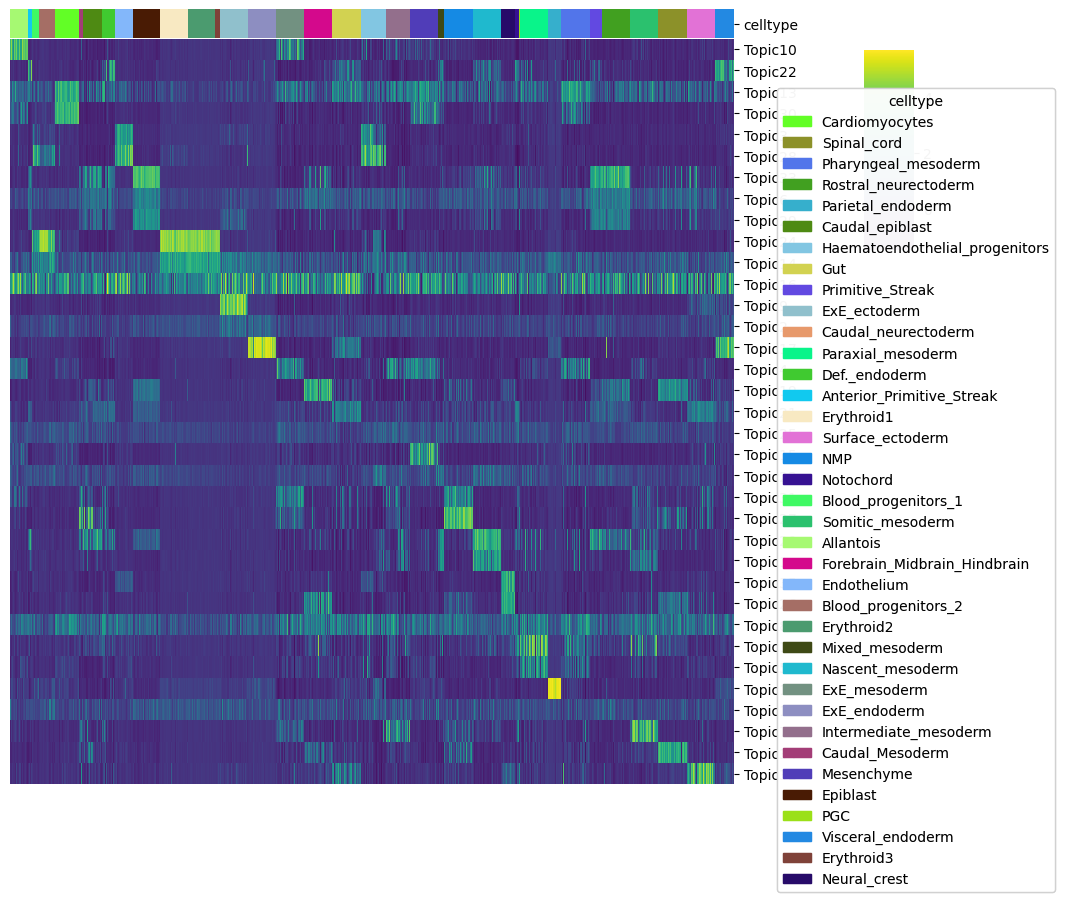

In [27]:
cell_topic_heatmap(cistopic_obj,
                     variables = ['celltype'],
                     scale = True,
                     legend_loc_x = 1.05,
                     legend_loc_y = -1.2,
                     legend_dist_y = -1,
                     figsize=(10,10),
                     save = outDir + 'visualization/heatmap_topic_contr.pdf')

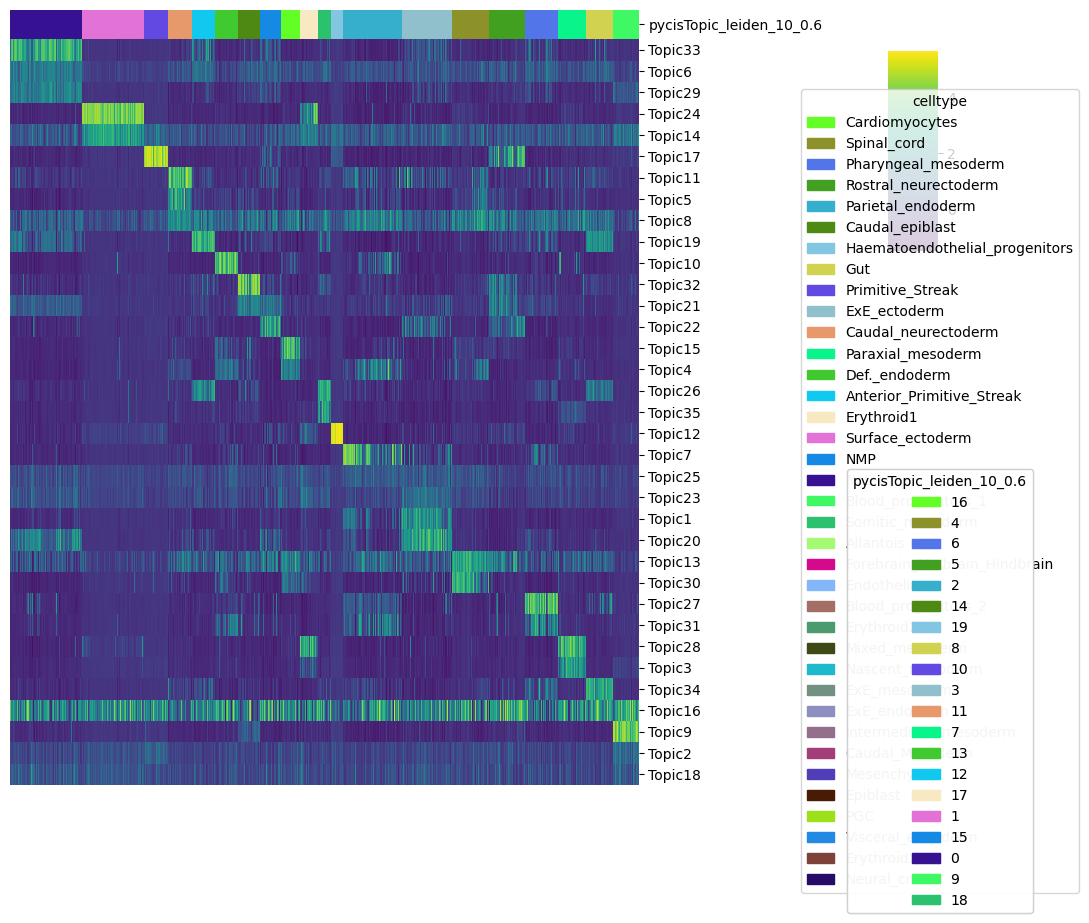

In [28]:
cell_topic_heatmap(cistopic_obj,
                     variables = ['pycisTopic_leiden_10_0.6'],
                     scale = True,
                     legend_loc_x = 1.05,
                     legend_loc_y = -1.2,
                     legend_dist_y = -1,
                     figsize=(10,10),
                     save = outDir + 'visualization/heatmap_topic_contr_clusters.pdf')

In [29]:
# Save
with open(outDir + 'cisTopicObject.pkl', 'wb') as f:
  pickle.dump(cistopic_obj, f)

## 5. Topic binarization & qc

In [30]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

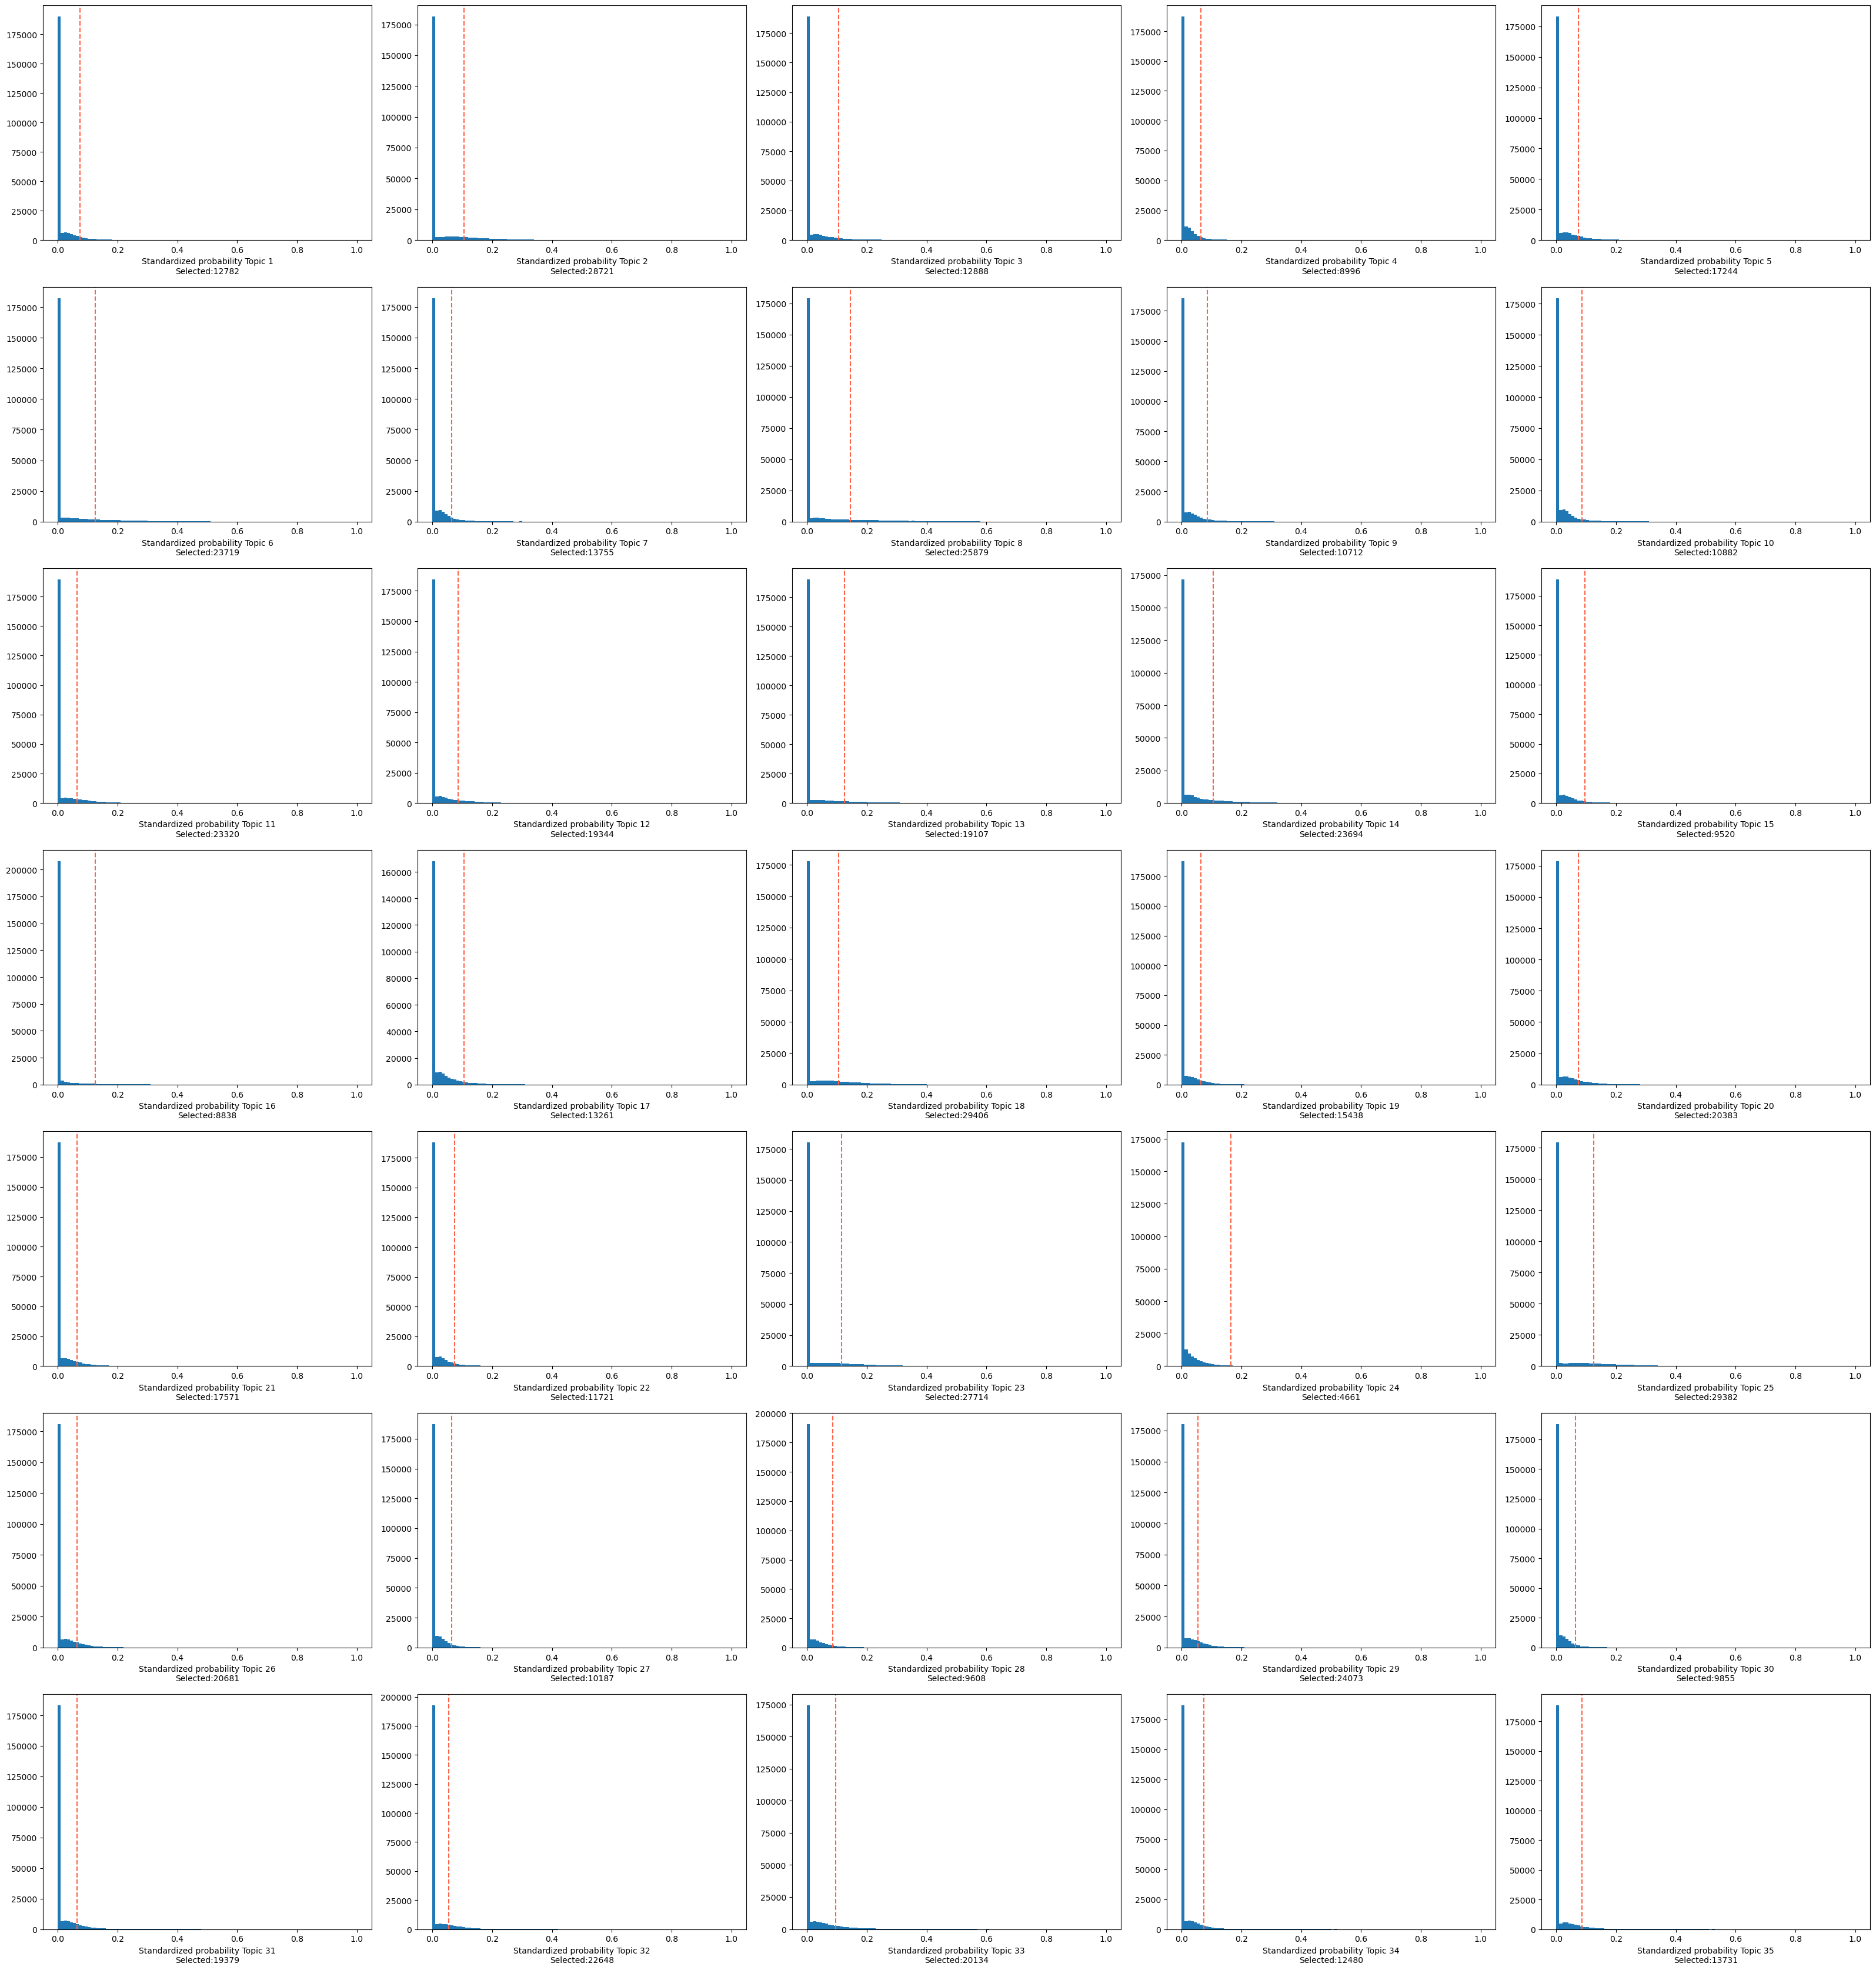

In [31]:
os.mkdir(outDir+'topic_binarization')
from pycisTopic.topic_binarization import *
region_bin_topics = binarize_topics(cistopic_obj, method='otsu', ntop=3000, plot=True, num_columns=5, save= outDir + 'topic_binarization/otsu.pdf')

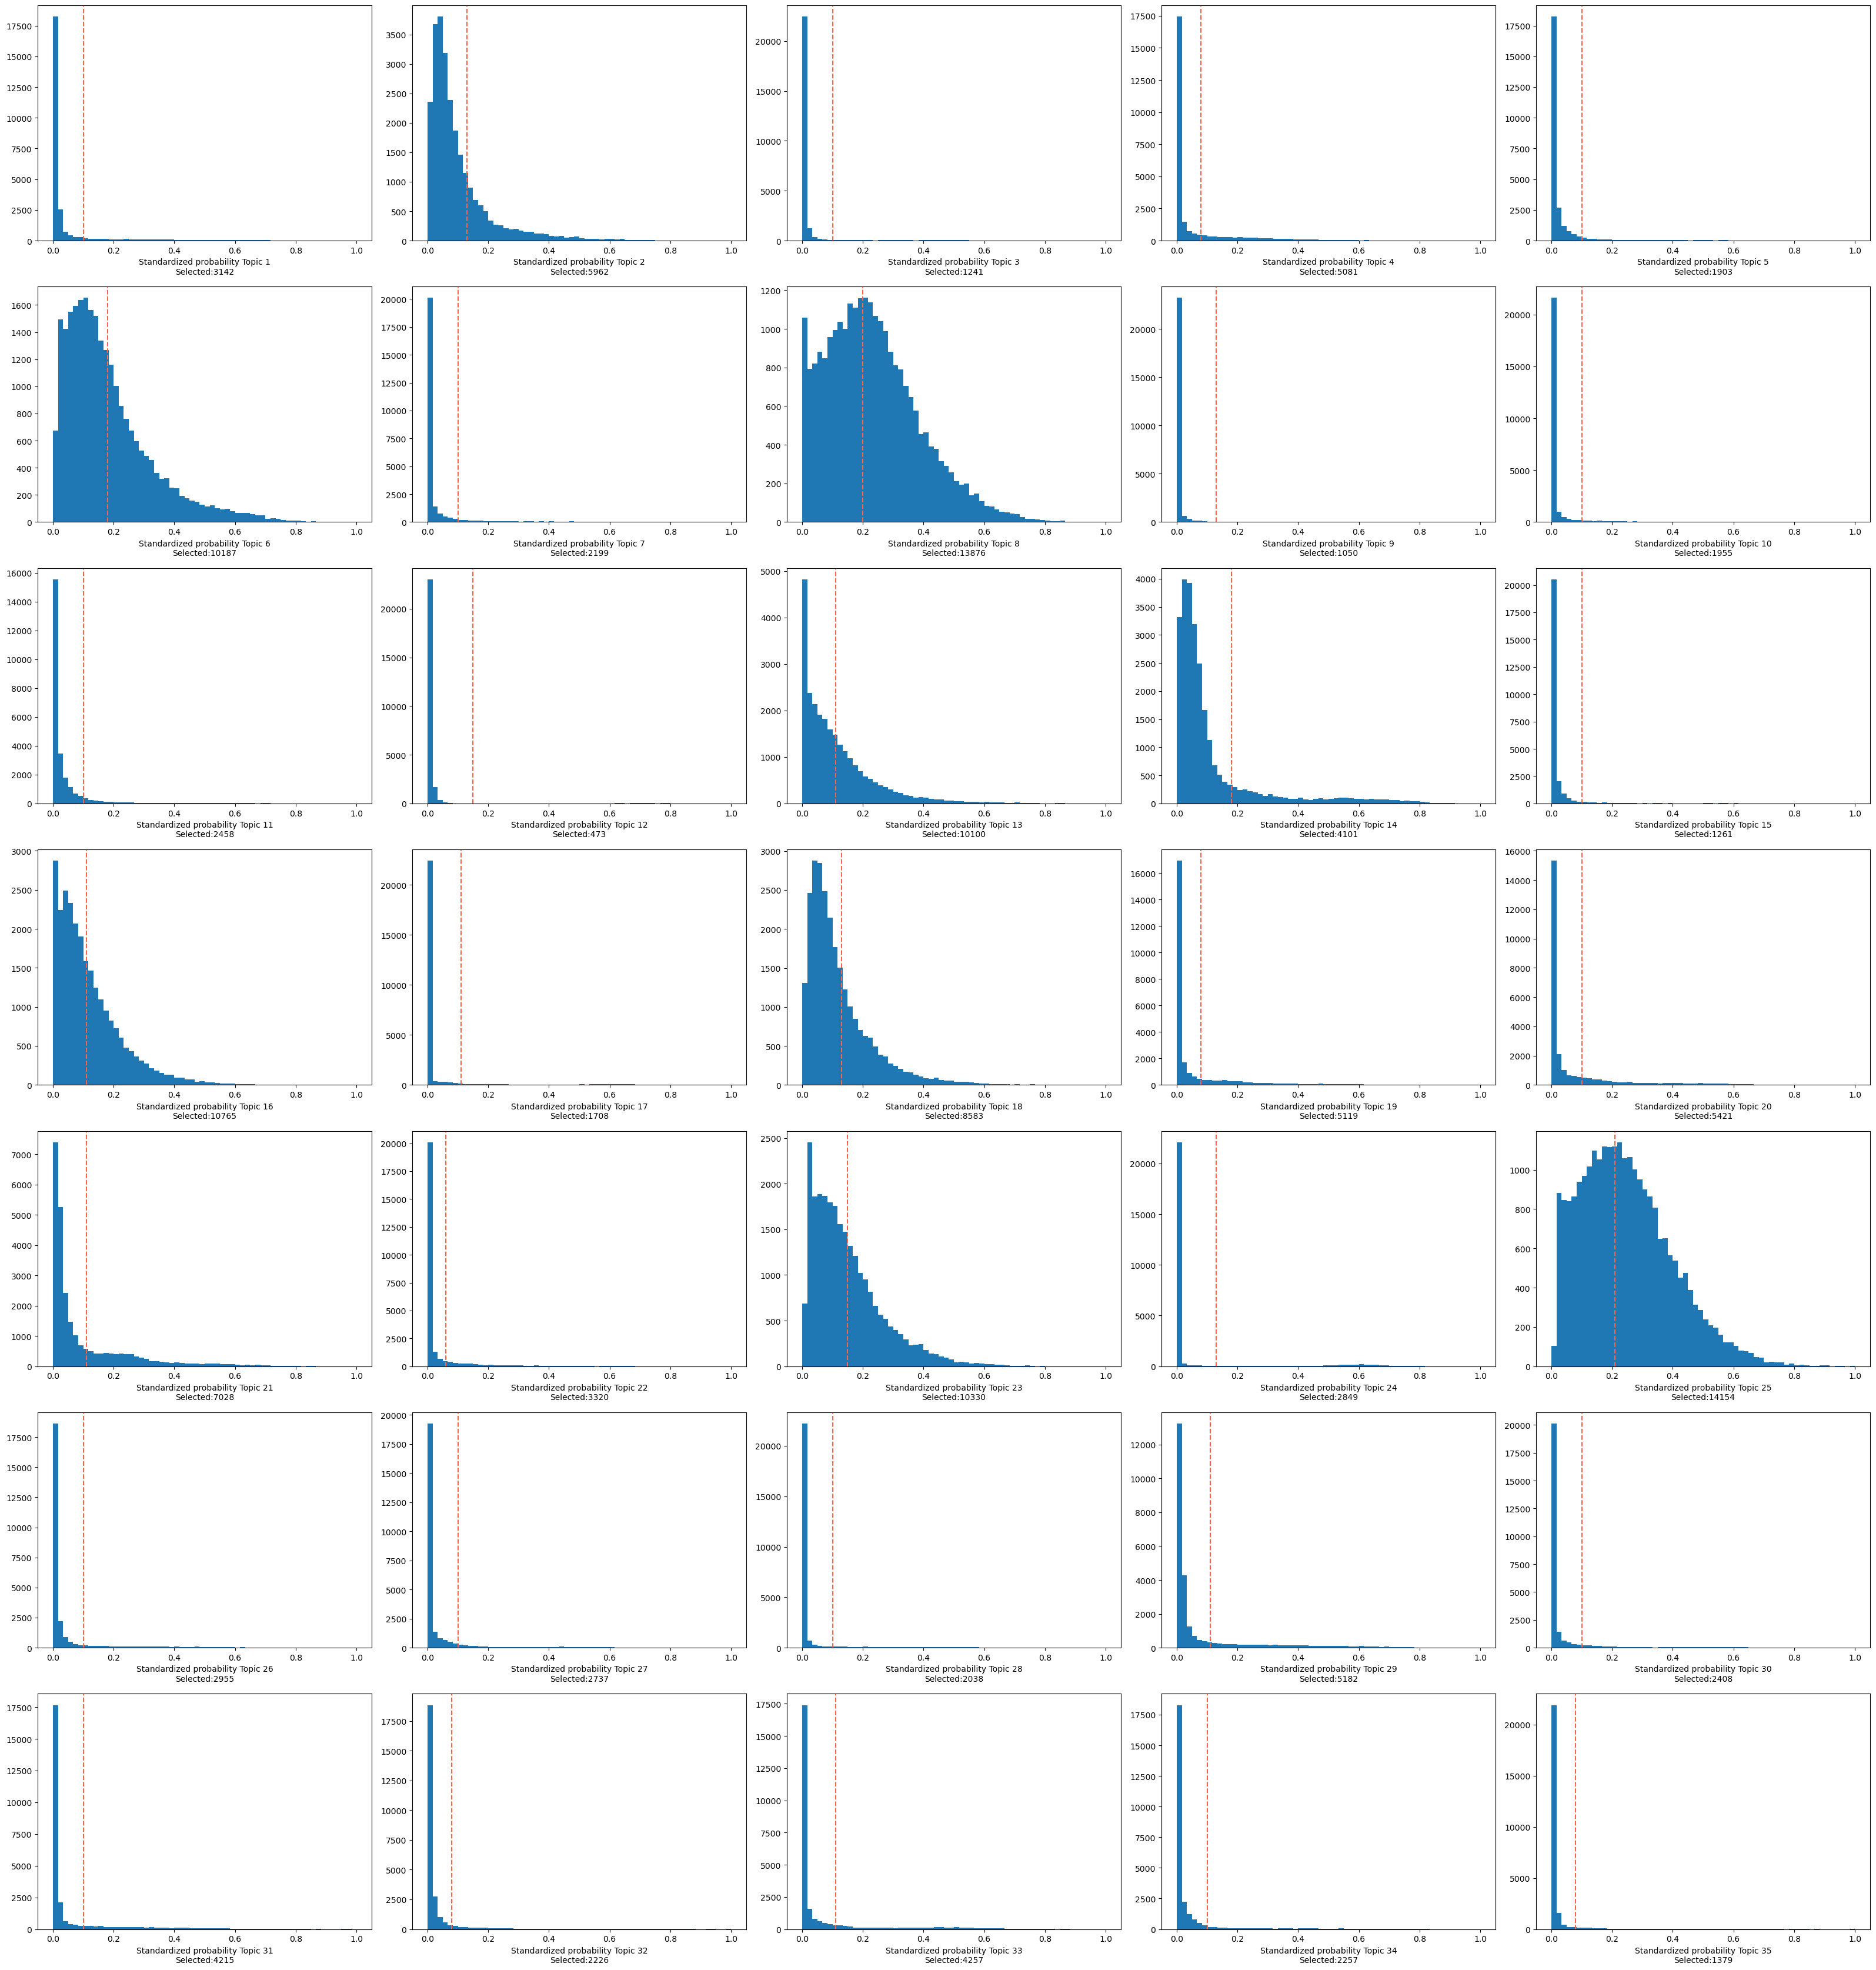

In [32]:
binarized_cell_topic = binarize_topics(cistopic_obj, target='cell', method='li', plot=True, num_columns=5, nbins=60)

In [33]:
from pycisTopic.topic_qc import *
topic_qc_metrics = compute_topic_metrics(cistopic_obj)

In [34]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Log10_Assignments', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['AssignmentsVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Log10_Assignments', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSCells_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Cells_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSRegions_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Regions_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSMarginal_dist']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSGini_index']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', var_color='Gini_index', plot=False, return_fig=True)

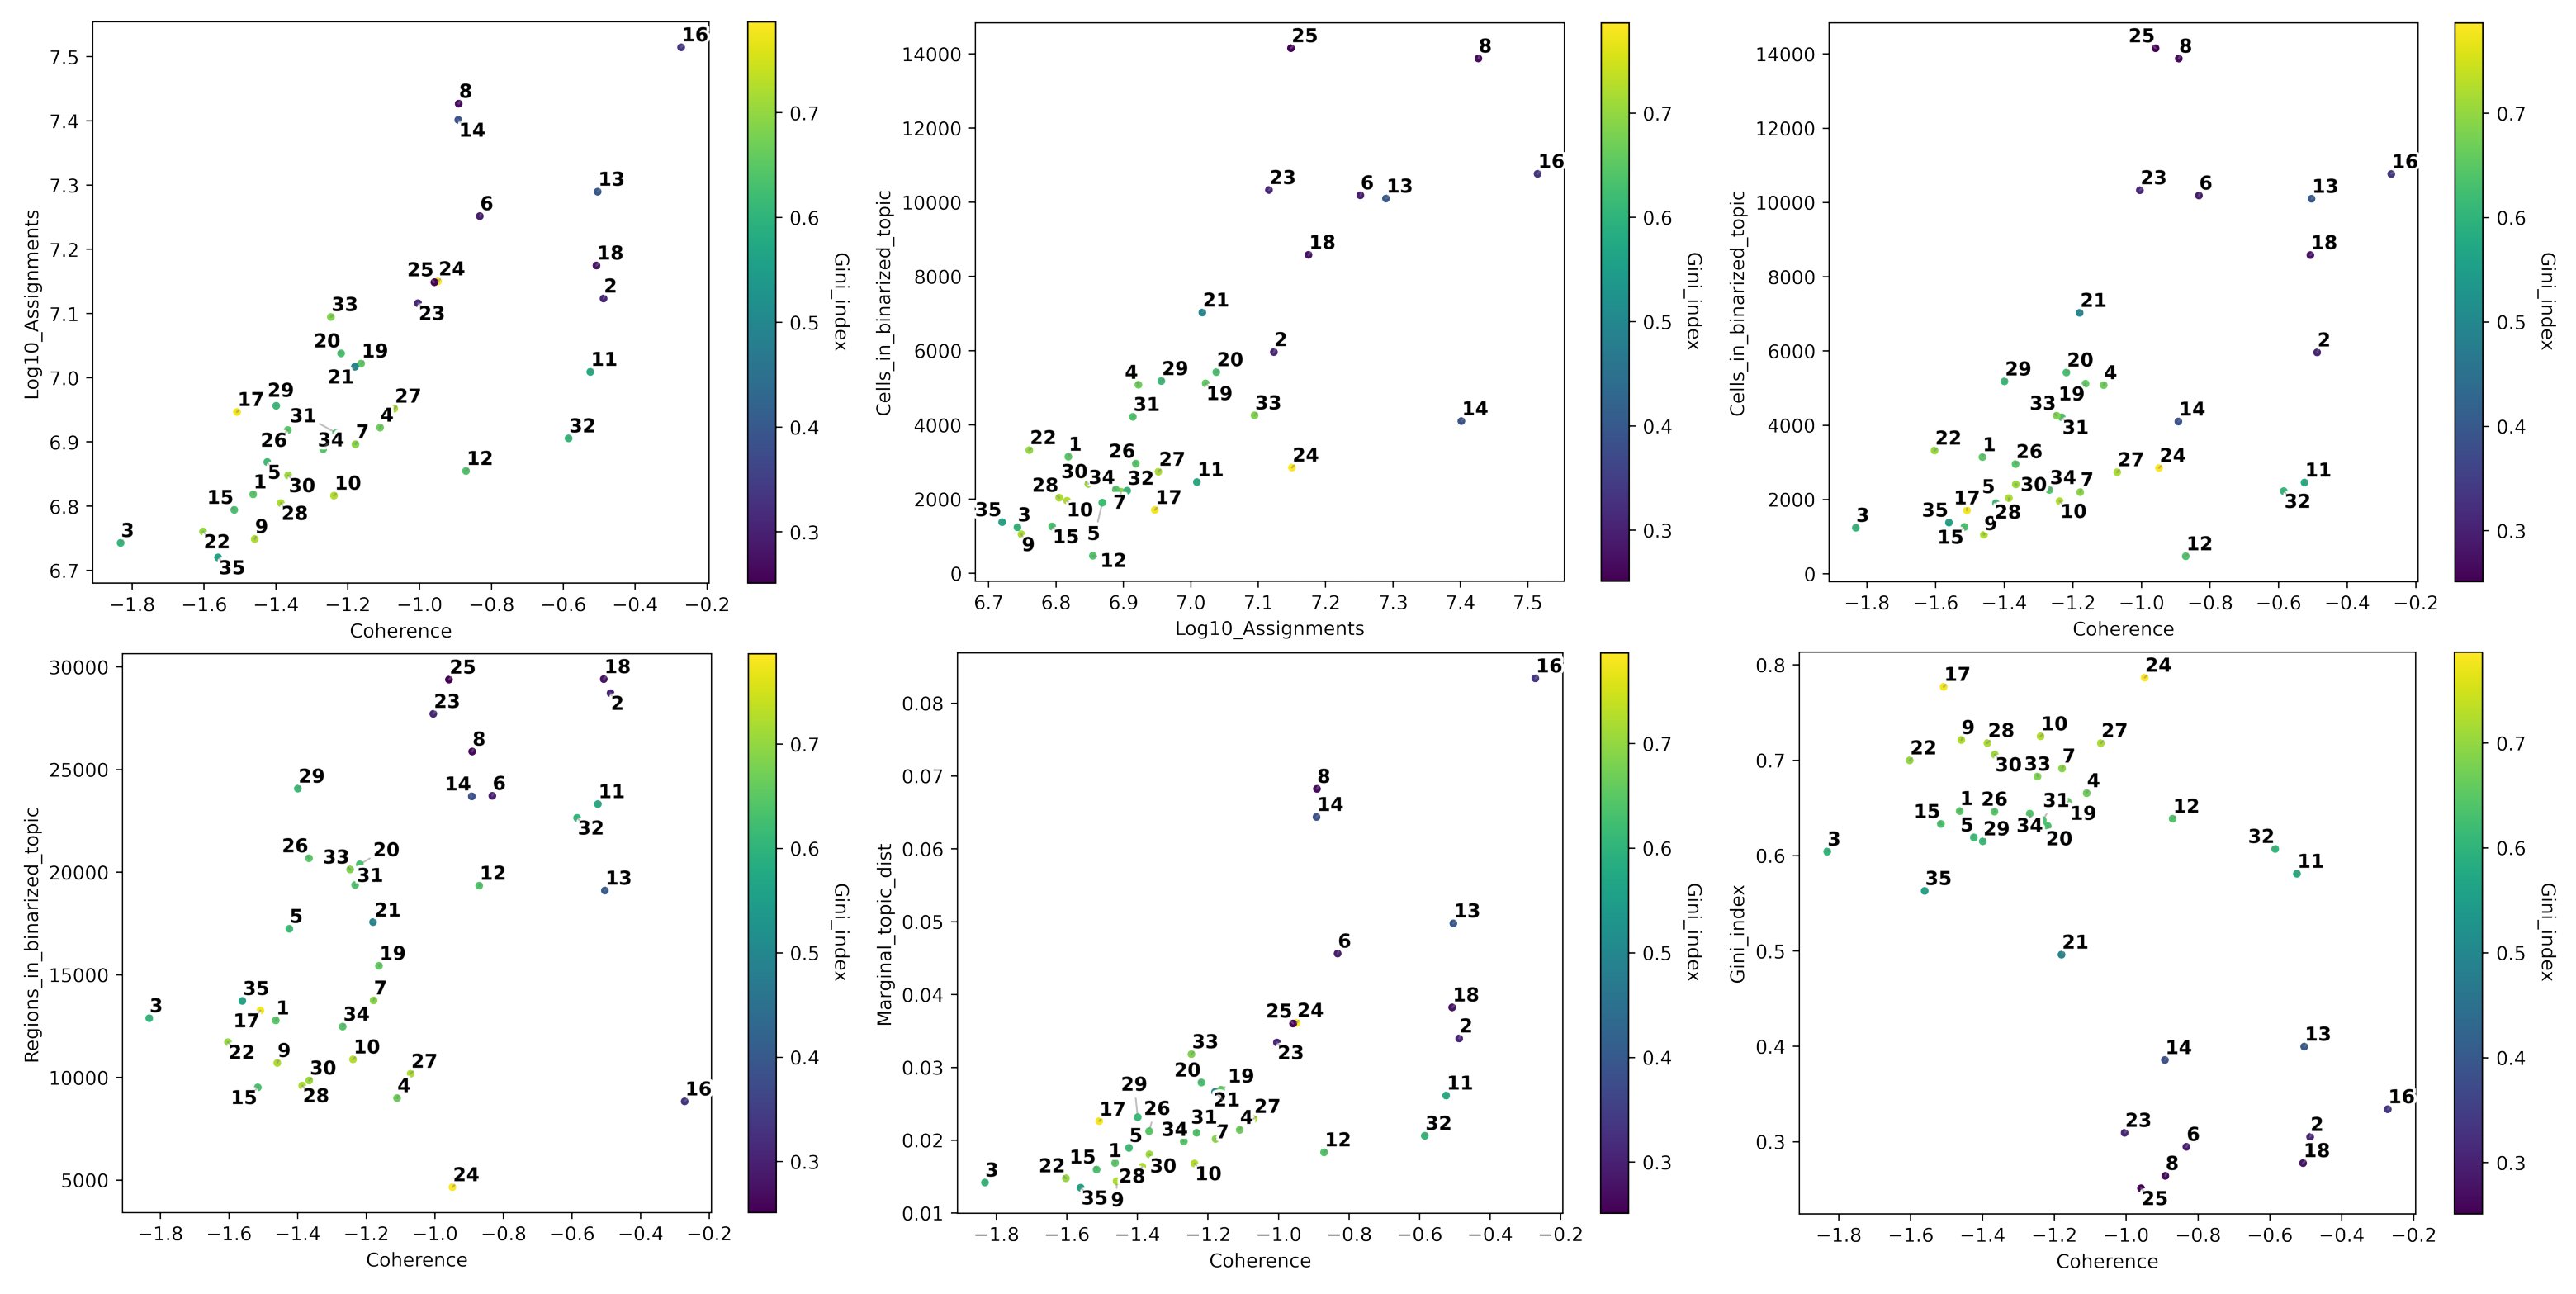

In [35]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
fig.savefig(outDir + 'topic_binarization/Topic_qc.pdf', bbox_inches='tight')
plt.show()

In [36]:
topic_annot = topic_annotation(cistopic_obj, annot_var='celltype', binarized_cell_topic=binarized_cell_topic, general_topic_thr = 0.2)

In [37]:
topic_annot

,celltype,Ratio_cells_in_topic,Ratio_group_in_population,is_general
Topic1,"Caudal_epiblast, Anterior_Primitive_Streak, So...",0.122424,0.150906,False
Topic2,"Parietal_endoderm, ExE_ectoderm, Erythroid1, B...",0.232301,0.227041,False
Topic3,"Haematoendothelial_progenitors, Blood_progenit...",0.048354,0.070212,False
Topic4,"Cardiomyocytes, Pharyngeal_mesoderm, Paraxial_...",0.197974,0.246133,False
Topic5,"Pharyngeal_mesoderm, Paraxial_mesoderm, Somiti...",0.074148,0.116891,False
Topic6,"Spinal_cord, Rostral_neurectoderm, Caudal_epib...",0.396922,0.407013,False
Topic7,"NMP, Notochord, Somitic_mesoderm, ExE_mesoderm...",0.085681,0.160296,False
Topic8,"Cardiomyocytes, Spinal_cord, Pharyngeal_mesode...",0.540658,0.39474,False
Topic9,ExE_ectoderm,0.040912,0.038964,False
Topic10,"Haematoendothelial_progenitors, Allantois, ExE...",0.076174,0.170933,False


In [38]:
topic_qc_metrics = pd.concat([topic_annot[['celltype', 'Ratio_cells_in_topic', 'Ratio_group_in_population']], topic_qc_metrics], axis=1)

In [39]:
topic_qc_metrics

,celltype,Ratio_cells_in_topic,Ratio_group_in_population,Log10_Assignments,Assignments,Regions_in_binarized_topic,Cells_in_binarized_topic,Coherence,Marginal_topic_dist,Gini_index
Topic1,"Caudal_epiblast, Anterior_Primitive_Streak, So...",0.122424,0.150906,6.818351,6581903.0,12782,3142,-1.463358,0.016883,0.646786
Topic2,"Parietal_endoderm, ExE_ectoderm, Erythroid1, B...",0.232301,0.227041,7.123286,13282681.0,28721,5962,-0.487952,0.033978,0.305049
Topic3,"Haematoendothelial_progenitors, Blood_progenit...",0.048354,0.070212,6.742773,5530613.0,12888,1241,-1.832254,0.014200,0.604279
Topic4,"Cardiomyocytes, Pharyngeal_mesoderm, Paraxial_...",0.197974,0.246133,6.922288,8361572.0,8996,5081,-1.109991,0.021427,0.665561
Topic5,"Pharyngeal_mesoderm, Paraxial_mesoderm, Somiti...",0.074148,0.116891,6.868694,7390850.0,17244,1903,-1.424034,0.018952,0.619144
Topic6,"Spinal_cord, Rostral_neurectoderm, Caudal_epib...",0.396922,0.407013,7.251600,17848411.0,23719,10187,-0.832455,0.045635,0.294694
Topic7,"NMP, Notochord, Somitic_mesoderm, ExE_mesoderm...",0.085681,0.160296,6.896234,7874704.0,13755,2199,-1.178522,0.020186,0.691393
Topic8,"Cardiomyocytes, Spinal_cord, Pharyngeal_mesode...",0.540658,0.39474,7.426648,26708403.0,25879,13876,-0.891163,0.068242,0.264259
Topic9,ExE_ectoderm,0.040912,0.038964,6.748804,5607949.0,10712,1050,-1.459070,0.014385,0.721298
Topic10,"Haematoendothelial_progenitors, Allantois, ExE...",0.076174,0.170933,6.816387,6552194.0,10882,1955,-1.238336,0.016811,0.725170


In [40]:
# Save
with open(outDir + 'topic_binarization/Topic_qc_metrics_annot.pkl', 'wb') as f:
  pickle.dump(topic_qc_metrics, f)
with open(outDir + 'topic_binarization/binarized_cell_topic.pkl', 'wb') as f:
  pickle.dump(binarized_cell_topic, f)
with open(outDir + 'topic_binarization/binarized_topic_region.pkl', 'wb') as f:
  pickle.dump(region_bin_topics, f)

## 6. Differentially Accessible Regions (DARs)

In [41]:
# Load cisTopic object
import pickle
infile = open(outDir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [42]:
from pycisTopic.diff_features import *
imputed_acc_obj = impute_accessibility(cistopic_obj, selected_cells=None, selected_regions=None, scale_factor=10**6)

2024-11-01 10:08:10,634 cisTopic     INFO     Imputing drop-outs
2024-11-01 10:08:23,189 cisTopic     INFO     Scaling
2024-11-01 10:08:34,327 cisTopic     INFO     Keep non zero rows
2024-11-01 10:08:48,871 cisTopic     INFO     Imputed accessibility sparsity: 0.3192516877602418
2024-11-01 10:08:48,872 cisTopic     INFO     Create CistopicImputedFeatures object
2024-11-01 10:08:48,872 cisTopic     INFO     Done!


In [43]:
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

2024-11-01 10:08:48,876 cisTopic     INFO     Normalizing imputed data
2024-11-01 10:09:53,961 cisTopic     INFO     Done!


2024-11-01 10:09:54,169 cisTopic     INFO     Calculating mean
2024-11-01 10:10:01,772 cisTopic     INFO     Calculating variance


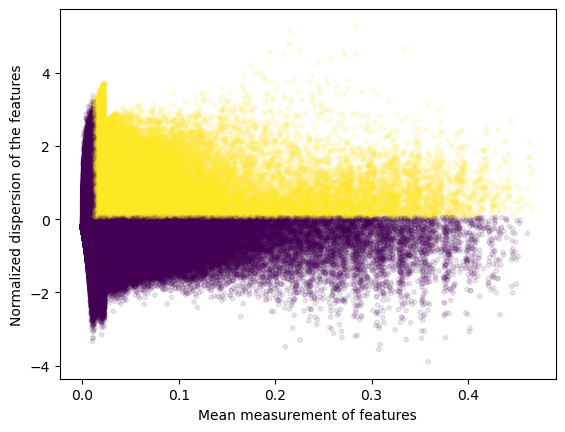

2024-11-01 10:10:53,478 cisTopic     INFO     Done!


In [44]:
os.mkdir(outDir+'DARs')
variable_regions = find_highly_variable_features(normalized_imputed_acc_obj,
                                           min_disp = 0.05,
                                           min_mean = 0.0125,
                                           max_mean = 3,
                                           max_disp = np.inf,
                                           n_bins=20,
                                           n_top_features=None,
                                           plot=True,
                                           save= outDir + 'DARs/HVR_plot.pdf')

In [49]:
len(variable_regions)

65025

In [55]:
ray.shutdown()

In [56]:
markers_dict= find_diff_features(cistopic_obj,
                      imputed_acc_obj,
                      variable='celltype',
                      var_features=variable_regions,
                      contrasts=None,
                      adjpval_thr=0.05,
                      log2fc_thr=np.log2(1.5),
                      n_cpu=5,
                      _temp_dir=tmpDir,
                      split_pattern = '-')

2024-11-01 10:29:08,494	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8266


(markers_ray pid=3950689) 2024-11-01 10:29:16,507 cisTopic     INFO     Formatting data for Blood_progenitors_1
(markers_ray pid=3950688) 2024-11-01 10:29:16,508 cisTopic     INFO     Formatting data for Cardiomyocytes
(markers_ray pid=3950687) 2024-11-01 10:29:16,507 cisTopic     INFO     Formatting data for Blood_progenitors_2
(markers_ray pid=3950691) 2024-11-01 10:29:16,507 cisTopic     INFO     Formatting data for Anterior_Primitive_Streak
(markers_ray pid=3950690) 2024-11-01 10:29:16,508 cisTopic     INFO     Formatting data for Allantois


(raylet) Spilled 6368 MiB, 1 objects, write throughput 982 MiB/s. Set RAY_verbose_spill_logs=0 to disable this message.
(raylet) Spilled 12738 MiB, 3 objects, write throughput 1517 MiB/s.
(raylet) Spilled 19108 MiB, 5 objects, write throughput 1454 MiB/s.
(raylet) Spilled 25478 MiB, 7 objects, write throughput 1125 MiB/s.


(markers_ray pid=3950689) 2024-11-01 10:29:55,910 cisTopic     INFO     Computing p-value for Blood_progenitors_1
(markers_ray pid=3950691) 2024-11-01 10:30:03,388 cisTopic     INFO     Computing p-value for Anterior_Primitive_Streak
(markers_ray pid=3950690) 2024-11-01 10:30:03,450 cisTopic     INFO     Computing p-value for Allantois
(markers_ray pid=3950687) 2024-11-01 10:30:05,271 cisTopic     INFO     Computing p-value for Blood_progenitors_2
(markers_ray pid=3950688) 2024-11-01 10:30:06,759 cisTopic     INFO     Computing p-value for Cardiomyocytes


(raylet) Spilled 89177 MiB, 27 objects, write throughput 1310 MiB/s.
(raylet) Spilled 95547 MiB, 29 objects, write throughput 1271 MiB/s.


(markers_ray pid=3950689) 2024-11-01 10:31:32,239 cisTopic     INFO     Computing log2FC for Blood_progenitors_1
(markers_ray pid=3950689) 2024-11-01 10:31:35,040 cisTopic     INFO     Blood_progenitors_1 done!
(markers_ray pid=3950689) 2024-11-01 10:31:35,186 cisTopic     INFO     Formatting data for Caudal_Mesoderm
(markers_ray pid=3950691) 2024-11-01 10:31:39,873 cisTopic     INFO     Computing log2FC for Anterior_Primitive_Streak
(markers_ray pid=3950690) 2024-11-01 10:31:40,722 cisTopic     INFO     Computing log2FC for Allantois
(markers_ray pid=3950691) 2024-11-01 10:31:42,246 cisTopic     INFO     Anterior_Primitive_Streak done!
(markers_ray pid=3950687) 2024-11-01 10:31:42,385 cisTopic     INFO     Computing log2FC for Blood_progenitors_2
(markers_ray pid=3950690) 2024-11-01 10:31:42,929 cisTopic     INFO     Allantois done!
(markers_ray pid=3950688) 2024-11-01 10:31:44,520 cisTopic     INFO     Computing log2FC for Cardiomyocytes
(markers_ray pid=3950687) 2024-11-01 10:31:44,

(raylet) Spilled 133769 MiB, 46 objects, write throughput 1325 MiB/s.


(markers_ray pid=3950690) 2024-11-01 10:32:19,194 cisTopic     INFO     Computing p-value for Caudal_epiblast
(markers_ray pid=3950691) 2024-11-01 10:32:32,682 cisTopic     INFO     Computing p-value for Def._endoderm
(markers_ray pid=3950687) 2024-11-01 10:32:34,947 cisTopic     INFO     Computing p-value for Caudal_neurectoderm
(markers_ray pid=3950688) 2024-11-01 10:32:35,517 cisTopic     INFO     Computing p-value for Endothelium
(markers_ray pid=3950689) 2024-11-01 10:32:54,984 cisTopic     INFO     Computing p-value for Caudal_Mesoderm
(markers_ray pid=3950690) 2024-11-01 10:33:50,254 cisTopic     INFO     Computing log2FC for Caudal_epiblast
(markers_ray pid=3950690) 2024-11-01 10:33:52,334 cisTopic     INFO     Caudal_epiblast done!
(markers_ray pid=3950690) 2024-11-01 10:33:52,418 cisTopic     INFO     Formatting data for Epiblast
(markers_ray pid=3950691) 2024-11-01 10:34:03,861 cisTopic     INFO     Computing log2FC for Def._endoderm
(markers_ray pid=3950687) 2024-11-01 10:3

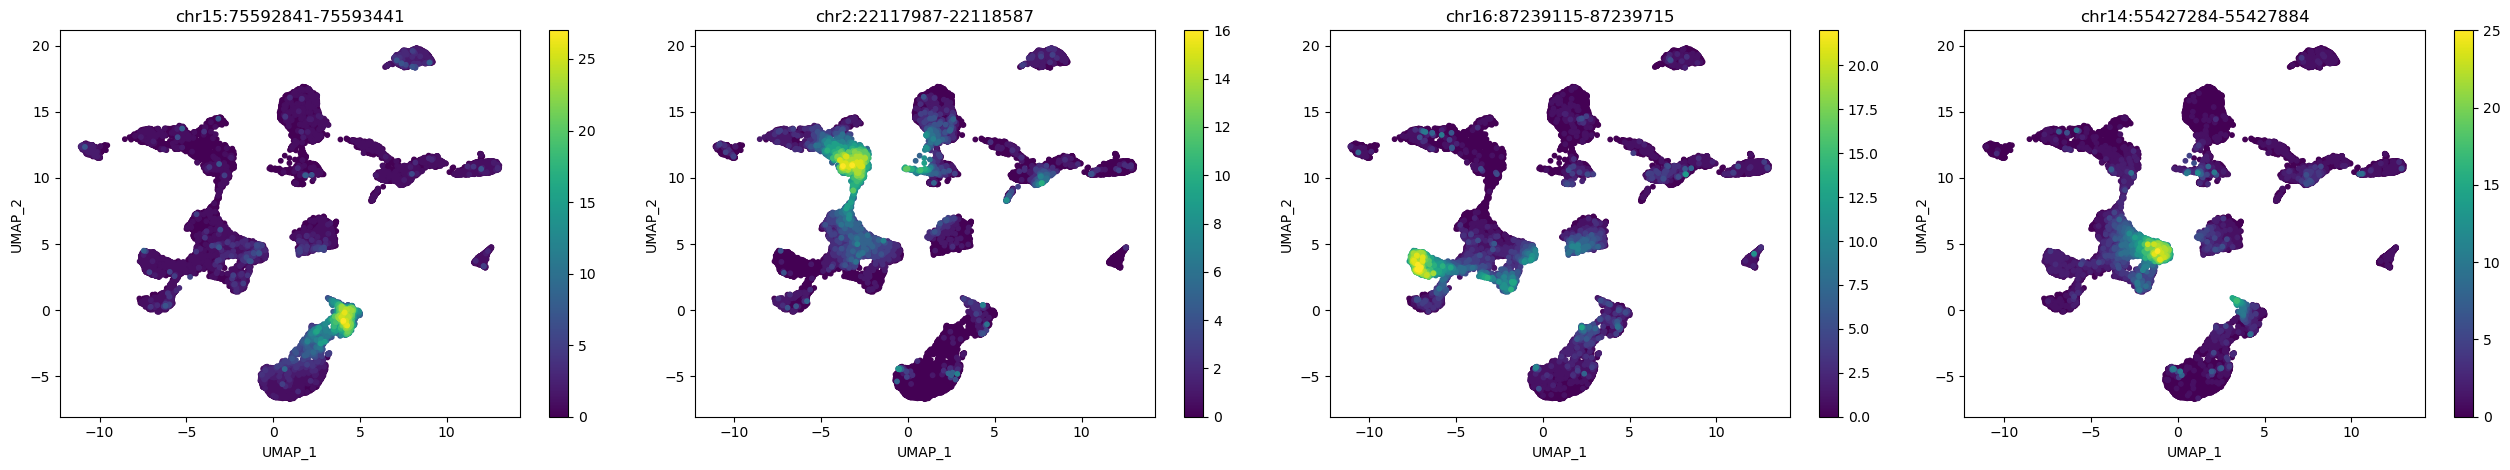

In [57]:
from pycisTopic.clust_vis import *
plot_imputed_features(cistopic_obj,
                    reduction_name='UMAP',
                    imputed_data=imputed_acc_obj,
                    features=[markers_dict[x].index.tolist()[0] for x in ['Endothelium', 'Caudal_Mesoderm', 'Cardiomyocytes', 'Allantois']],
                    scale=False,
                    num_columns=4,
                    save= outDir + 'DARs/example_best_DARs.pdf')

In [58]:
x = [print(x + ': '+ str(len(markers_dict[x]))) for x in markers_dict.keys()]

Allantois: 14981
Anterior_Primitive_Streak: 16398
Blood_progenitors_1: 10260
Blood_progenitors_2: 9825
Cardiomyocytes: 8315
Caudal_Mesoderm: 12375
Caudal_epiblast: 15691
Caudal_neurectoderm: 14911
Def._endoderm: 10233
Endothelium: 10667
Epiblast: 14866
Erythroid1: 9027
Erythroid2: 9230
Erythroid3: 9151
ExE_ectoderm: 10317
ExE_endoderm: 11159
ExE_mesoderm: 13577
Forebrain_Midbrain_Hindbrain: 10751
Gut: 7479
Haematoendothelial_progenitors: 10052
Intermediate_mesoderm: 12757
Mesenchyme: 12868
Mixed_mesoderm: 13155
NMP: 11931
Nascent_mesoderm: 14589
Neural_crest: 10167
Notochord: 10993
PGC: 17156
Paraxial_mesoderm: 8888
Parietal_endoderm: 9063
Pharyngeal_mesoderm: 8889
Primitive_Streak: 15141
Rostral_neurectoderm: 14394
Somitic_mesoderm: 12668
Spinal_cord: 10403
Surface_ectoderm: 7762
Visceral_endoderm: 12872


In [59]:
if not os.path.exists(os.path.join(work_dir, 'scATAC/candidate_enhancers')):
    os.makedirs(os.path.join(work_dir, 'scATAC/candidate_enhancers'))
import pickle
pickle.dump(markers_dict, open(os.path.join(work_dir, 'scATAC/candidate_enhancers/markers_dict.pkl'), 'wb'))
pickle.dump(imputed_acc_obj, open(outDir + 'DARs/Imputed_accessibility.pkl', 'wb'))

# Motif enrichment analysis using pycistarget

In [1]:
import sys
import scipy as sc
import pandas as pd
sys.path
tmpDir = '/home/bt392/ry/'

import warnings
warnings.simplefilter(action='ignore')
import pycisTopic
pycisTopic.__version__

# Project directory
projDir = '/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus_sc/'
# Output directory
outDir = projDir + 'pycistopic/'
import os
if not os.path.exists(outDir):
    os.makedirs(outDir)
work_dir = outDir

In [2]:
import pickle
region_bin_topics_otsu = pickle.load(open(os.path.join(work_dir, 'topic_binarization/binarized_topic_region.pkl'), 'rb'))
#region_bin_topics_top3k = pickle.load(open(os.path.join(work_dir, 'scATAC/candidate_enhancers/region_bin_topics_top3k.pkl'), 'rb'))
markers_dict = pickle.load(open(os.path.join(work_dir, 'scATAC/candidate_enhancers/markers_dict.pkl'), 'rb'))

In [3]:
import pyranges as pr
from pycistarget.utils import region_names_to_coordinates
region_sets = {}
region_sets['topics_otsu'] = {}
# region_sets['topics_top_3'] = {}
region_sets['DARs'] = {}
for topic in region_bin_topics_otsu.keys():
    regions = region_bin_topics_otsu[topic].index[region_bin_topics_otsu[topic].index.str.startswith('chr')] #only keep regions on known chromosomes
    region_sets['topics_otsu'][topic] = pr.PyRanges(region_names_to_coordinates(regions))
# for topic in region_bin_topics_top3k.keys():
#     regions = region_bin_topics_top3k[topic].index[region_bin_topics_top3k[topic].index.str.startswith('chr')] #only keep regions on known chromosomes
#     region_sets['topics_top_3'][topic] = pr.PyRanges(region_names_to_coordinates(regions))
for DAR in markers_dict.keys():
    regions = markers_dict[DAR].index[markers_dict[DAR].index.str.startswith('chr')] #only keep regions on known chromosomes
    region_sets['DARs'][DAR] = pr.PyRanges(region_names_to_coordinates(regions))

In [4]:
for key in region_sets.keys():
    print(f'{key}: {region_sets[key].keys()}')

topics_otsu: dict_keys(['Topic1', 'Topic2', 'Topic3', 'Topic4', 'Topic5', 'Topic6', 'Topic7', 'Topic8', 'Topic9', 'Topic10', 'Topic11', 'Topic12', 'Topic13', 'Topic14', 'Topic15', 'Topic16', 'Topic17', 'Topic18', 'Topic19', 'Topic20', 'Topic21', 'Topic22', 'Topic23', 'Topic24', 'Topic25', 'Topic26', 'Topic27', 'Topic28', 'Topic29', 'Topic30', 'Topic31', 'Topic32', 'Topic33', 'Topic34', 'Topic35'])
DARs: dict_keys(['Allantois', 'Anterior_Primitive_Streak', 'Blood_progenitors_1', 'Blood_progenitors_2', 'Cardiomyocytes', 'Caudal_Mesoderm', 'Caudal_epiblast', 'Caudal_neurectoderm', 'Def._endoderm', 'Endothelium', 'Epiblast', 'Erythroid1', 'Erythroid2', 'Erythroid3', 'ExE_ectoderm', 'ExE_endoderm', 'ExE_mesoderm', 'Forebrain_Midbrain_Hindbrain', 'Gut', 'Haematoendothelial_progenitors', 'Intermediate_mesoderm', 'Mesenchyme', 'Mixed_mesoderm', 'NMP', 'Nascent_mesoderm', 'Neural_crest', 'Notochord', 'PGC', 'Paraxial_mesoderm', 'Parietal_endoderm', 'Pharyngeal_mesoderm', 'Primitive_Streak', 'Ro

In [5]:
db_fpath = "/rds/project/rds-SDzz0CATGms/users/bt392/software/cistarget_database/mm10"
motif_annot_fpath = "/rds/project/rds-SDzz0CATGms/users/bt392/software/cistarget_database/mm10"

In [6]:
rankings_db = os.path.join(db_fpath, 'mm10_screen_v10_clust.regions_vs_motifs.rankings.feather')
scores_db =  os.path.join(db_fpath, 'mm10_screen_v10_clust.regions_vs_motifs.scores.feather')
motif_annotation = os.path.join(motif_annot_fpath, 'motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl')

In [7]:
if not os.path.exists(os.path.join(work_dir, 'motifs')):
    os.makedirs(os.path.join(work_dir, 'motifs'))

In [8]:
from scenicplus.wrappers.run_pycistarget import run_pycistarget
run_pycistarget(
    region_sets = region_sets,
    species = 'mus_musculus',
    save_path = os.path.join(work_dir, 'motifs'),
    ctx_db_path = rankings_db,
    dem_db_path = scores_db,
    path_to_motif_annotations = motif_annotation,
    run_without_promoters = False,
    n_cpu = 5,
    _temp_dir = tmpDir,
    annotation_version = 'v10nr_clust',
    )

2024-11-01 10:59:46,700 pycisTarget_wrapper INFO     /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus_sc/pycistopic/motifs folder already exists.
2024-11-01 10:59:47,403 pycisTarget_wrapper INFO     Loading cisTarget database for topics_otsu
2024-11-01 10:59:47,403 cisTarget    INFO     Reading cisTarget database
2024-11-01 11:01:21,603 pycisTarget_wrapper INFO     Running cisTarget for topics_otsu


2024-11-01 11:01:23,270	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8265


(ctx_internal_ray pid=3958798) 2024-11-01 11:01:26,190 cisTarget    INFO     Running cisTarget for Topic1 which has 14504 regions
(ctx_internal_ray pid=3958799) 2024-11-01 11:01:27,051 cisTarget    INFO     Running cisTarget for Topic2 which has 33886 regions
(ctx_internal_ray pid=3958797) 2024-11-01 11:01:27,919 cisTarget    INFO     Running cisTarget for Topic3 which has 15197 regions
(ctx_internal_ray pid=3958795) 2024-11-01 11:01:28,818 cisTarget    INFO     Running cisTarget for Topic4 which has 11466 regions
(ctx_internal_ray pid=3958796) 2024-11-01 11:01:29,760 cisTarget    INFO     Running cisTarget for Topic5 which has 23289 regions
(ctx_internal_ray pid=3958798) 2024-11-01 11:01:36,021 cisTarget    INFO     Annotating motifs for Topic1
(ctx_internal_ray pid=3958797) 2024-11-01 11:01:37,078 cisTarget    INFO     Annotating motifs for Topic3
(ctx_internal_ray pid=3958795) 2024-11-01 11:01:37,568 cisTarget    INFO     Annotating motifs for Topic4
(ctx_internal_ray pid=3958798) 2

2024-11-01 11:06:05,301	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8265


(DEM_internal_ray pid=3959781) 2024-11-01 11:06:19,311 DEM          INFO     Computing DEM for Topic4
(DEM_internal_ray pid=3959784) 2024-11-01 11:06:19,997 DEM          INFO     Computing DEM for Topic1
(DEM_internal_ray pid=3959783) 2024-11-01 11:06:20,067 DEM          INFO     Computing DEM for Topic3
(DEM_internal_ray pid=3959780) 2024-11-01 11:06:22,365 DEM          INFO     Computing DEM for Topic5
(DEM_internal_ray pid=3959782) 2024-11-01 11:06:23,768 DEM          INFO     Computing DEM for Topic2
2024-11-01 11:14:30,072 DEM          INFO     Forming cistromes
2024-11-01 11:14:39,579 DEM          INFO     Done!
2024-11-01 11:14:48,592 pycisTarget_wrapper INFO     Created folder : /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus_sc/pycistopic/motifs/DEM_topics_otsu_All
2024-11-01 11:14:49,096 pycisTarget_wrapper INFO     Loading cisTarget database for DARs
2024-11-01 11:14:49,097 cisTarget    INFO     Reading cisTarget database
202

2024-11-01 11:16:36,664	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8265


(ctx_internal_ray pid=3960822) 2024-11-01 11:16:46,223 cisTarget    INFO     Running cisTarget for Blood_progenitors_1 which has 12073 regions
(ctx_internal_ray pid=3960821) 2024-11-01 11:16:46,222 cisTarget    INFO     Running cisTarget for Cardiomyocytes which has 9710 regions
(ctx_internal_ray pid=3960823) 2024-11-01 11:16:46,224 cisTarget    INFO     Running cisTarget for Anterior_Primitive_Streak which has 17999 regions
(ctx_internal_ray pid=3960820) 2024-11-01 11:16:46,223 cisTarget    INFO     Running cisTarget for Blood_progenitors_2 which has 11712 regions
(ctx_internal_ray pid=3960819) 2024-11-01 11:16:46,224 cisTarget    INFO     Running cisTarget for Allantois which has 17025 regions
(ctx_internal_ray pid=3960821) 2024-11-01 11:16:55,951 cisTarget    INFO     Annotating motifs for Cardiomyocytes
(ctx_internal_ray pid=3960820) 2024-11-01 11:16:56,156 cisTarget    INFO     Annotating motifs for Blood_progenitors_2
(ctx_internal_ray pid=3960822) 2024-11-01 11:16:56,567 cisTarg

2024-11-01 11:20:18,686	INFO services.py:1470 -- View the Ray dashboard at http://127.0.0.1:8265


(DEM_internal_ray pid=3961591) 2024-11-01 11:20:26,068 DEM          INFO     Computing DEM for Cardiomyocytes
(DEM_internal_ray pid=3961590) 2024-11-01 11:20:26,545 DEM          INFO     Computing DEM for Blood_progenitors_2
(DEM_internal_ray pid=3961589) 2024-11-01 11:20:26,936 DEM          INFO     Computing DEM for Blood_progenitors_1
(DEM_internal_ray pid=3961587) 2024-11-01 11:20:28,461 DEM          INFO     Computing DEM for Allantois
(DEM_internal_ray pid=3961588) 2024-11-01 11:20:28,594 DEM          INFO     Computing DEM for Anterior_Primitive_Streak
2024-11-01 11:24:03,218 DEM          INFO     Forming cistromes
2024-11-01 11:24:09,150 DEM          INFO     Done!
2024-11-01 11:24:15,261 pycisTarget_wrapper INFO     Created folder : /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas/SCENICplus_sc/pycistopic/motifs/DEM_DARs_All
2024-11-01 11:24:15,681 pycisTarget_wrapper INFO     Saving object
2024-11-01 11:34:32,446 pycisTarget_wrapper INFO 

In [9]:
import dill
menr = dill.load(open(os.path.join(work_dir, 'motifs/menr.pkl'), 'rb'))